does response time differ across wards?

In [1]:
# Load the Chicago 311 pothole data. .info() shows column types and non-null
# counts -- I check CLOSED_DATE coverage here because response time depends on it.

In [2]:
import pandas as pd
df = pd.read_csv("311ServiceRequests.csv")
print(df.shape)
df.info()

(76717, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76717 entries, 0 to 76716
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SR_NUMBER                 76717 non-null  object 
 1   SR_TYPE                   76717 non-null  object 
 2   SR_SHORT_CODE             76717 non-null  object 
 3   CREATED_DEPARTMENT        36235 non-null  object 
 4   OWNER_DEPARTMENT          76717 non-null  object 
 5   STATUS                    76717 non-null  object 
 6   ORIGIN                    76714 non-null  object 
 7   CREATED_DATE              76717 non-null  object 
 8   LAST_MODIFIED_DATE        76717 non-null  object 
 9   CLOSED_DATE               74638 non-null  object 
 10  STREET_ADDRESS            76608 non-null  object 
 11  CITY                      23092 non-null  object 
 12  STATE                     23092 non-null  object 
 13  ZIP_CODE                  62560 non-null  object 

C:\Users\dhanu\AppData\Local\Temp\ipykernel_4544\2514636969.py:2: DtypeWarning: Columns (13,20,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311ServiceRequests.csv")


In [3]:
# missing CLOSED_DATE likely = still-open requests; 
# dropping them may bias results; decide how to handle later.
# duplicates exist; one pothole may appear as many rows; handle before analysis.

In [4]:
# # Earliest request date confirms when the data starts.
df['CREATED_DATE'].min()

'01/01/2020 02:57:28 PM'

In [5]:
# Latest request date with the min, confirms the file spans 2020-2025.
df['CREATED_DATE'].max()

'12/31/2025 07:27:36 AM'

In [6]:
# Dates load as text, so I convert them to datetime before subtracting.
# response_days = time from request to close (/86400 converts seconds to days).
# The distribution is right-skewed, so I summarize with the median, not the mean.

df['CREATED_DATE'] = pd.to_datetime(df['CREATED_DATE'])
df['CLOSED_DATE'] = pd.to_datetime(df['CLOSED_DATE'])

df['response_days'] = (df['CLOSED_DATE'] - df['CREATED_DATE']).dt.total_seconds() / 86400

print(df['response_days'].describe())

C:\Users\dhanu\AppData\Local\Temp\ipykernel_4544\3342631128.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CREATED_DATE'] = pd.to_datetime(df['CREATED_DATE'])
C:\Users\dhanu\AppData\Local\Temp\ipykernel_4544\3342631128.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CLOSED_DATE'] = pd.to_datetime(df['CLOSED_DATE'])


count    74638.000000
mean        53.570372
std         67.100606
min          0.000278
25%          5.805706
50%         24.123918
75%         79.947714
max       1256.949757
Name: response_days, dtype: float64


In [7]:
# First pass at the fairness question: median response time per ward, fastest to slowest.
# Median (not mean) because the long tail of slow cases would distort an average.
df.groupby('WARD')['response_days'].median().sort_values()

WARD
42.0     4.891493
47.0     7.197292
43.0     7.664213
40.0     7.759398
7.0      9.728675
50.0    10.389340
44.0    10.841354
15.0    12.078987
34.0    13.087130
9.0     13.857986
48.0    13.859479
46.0    13.975486
49.0    14.223426
19.0    15.858385
13.0    16.970428
8.0     18.086001
32.0    18.576372
18.0    19.791198
6.0     20.167911
3.0     20.200602
33.0    20.334734
10.0    20.882413
12.0    21.682350
17.0    21.852361
21.0    23.445608
28.0    24.131244
16.0    25.031279
35.0    25.886389
2.0     26.608912
23.0    26.897384
39.0    27.775775
4.0     28.753814
11.0    28.788953
20.0    28.969028
1.0     30.805301
14.0    31.669525
5.0     33.023530
31.0    33.127095
38.0    33.134404
45.0    34.928513
26.0    35.920532
27.0    36.073837
41.0    36.772338
30.0    37.980625
36.0    39.829809
24.0    41.807135
29.0    42.038912
25.0    43.896354
37.0    47.874803
22.0    48.581354
Name: response_days, dtype: float64

In [8]:
# Per-ward table with BOTH median response time and request volume,
# so I can test whether slow wards are just high-volume (backlogged) wards.

ward_stats = df.groupby('WARD').agg(
    median_response=('response_days', 'median'),
    request_count=('response_days', 'count')
).sort_values('median_response')

print(ward_stats)

      median_response  request_count
WARD                                
42.0         4.891493            336
47.0         7.197292           2183
43.0         7.664213            995
40.0         7.759398           2016
7.0          9.728675            534
50.0        10.389340           1769
44.0        10.841354            946
15.0        12.078987           1992
34.0        13.087130            620
9.0         13.857986            837
48.0        13.859479           1601
46.0        13.975486            509
49.0        14.223426            768
19.0        15.858385           1504
13.0        16.970428            865
8.0         18.086001            858
32.0        18.576372           2676
18.0        19.791198            992
6.0         20.167911            774
3.0         20.200602            579
33.0        20.334734           2247
10.0        20.882413           1520
12.0        21.682350           1337
17.0        21.852361           1043
21.0        23.445608            938
2

In [9]:
# Correlation between a ward's response time and its request volume.
# Tests the 'backlog' explanation. Result ~0.33 -- weak-to-moderate.
ward_stats['median_response'].corr(ward_stats['request_count'])

0.3318196479069698

In [10]:
# Volume explains only ~11% of the response-time differences (0.33 squared).
# Since the disparity mostly survives the most obvious confounder, it's worth investigating
# whether neighborhood wealth explains the rest -- which is what the rest of this notebook tests.

In [11]:
# Switching the unit of analysis from ward to community area (better matched to income data).
# Checking the community-area numbers fall in the official 1-77 range before any join.

df['COMMUNITY_AREA'].describe()

count    76563.000000
mean        30.258833
std         22.001317
min          1.000000
25%         15.000000
50%         24.000000
75%         49.000000
max         77.000000
Name: COMMUNITY_AREA, dtype: float64

In [12]:
# List every distinct community-area value to confirm none fall outside 1-77 (e.g. a stray 0).

sorted(df['COMMUNITY_AREA'].dropna().unique())

[1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 18.0,
 19.0,
 20.0,
 21.0,
 22.0,
 23.0,
 24.0,
 25.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0,
 31.0,
 32.0,
 33.0,
 34.0,
 35.0,
 36.0,
 37.0,
 38.0,
 39.0,
 40.0,
 41.0,
 42.0,
 43.0,
 44.0,
 45.0,
 46.0,
 47.0,
 48.0,
 49.0,
 50.0,
 51.0,
 52.0,
 53.0,
 54.0,
 55.0,
 56.0,
 57.0,
 58.0,
 59.0,
 60.0,
 61.0,
 62.0,
 63.0,
 64.0,
 65.0,
 66.0,
 67.0,
 68.0,
 69.0,
 70.0,
 71.0,
 72.0,
 73.0,
 74.0,
 75.0,
 76.0,
 77.0]

In [13]:
# Does the 311 data have a community-area NAME column? (It only has the number --
# so I'll pull names from the income file later for readable chart labels.)

[c for c in df.columns if 'COMMUNITY' in c.upper()]

['COMMUNITY_AREA']

In [14]:
# Load the socioeconomic indicators file (2008-2012 ACS) and inspect its columns.

income = pd.read_csv("Income.csv")
income.columns

Index(['Community Area Number', 'COMMUNITY AREA NAME',
       'PERCENT OF HOUSING CROWDED', 'PERCENT HOUSEHOLDS BELOW POVERTY',
       'PERCENT AGED 16+ UNEMPLOYED',
       'PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA',
       'PERCENT AGED UNDER 18 OR OVER 64', 'PER CAPITA INCOME ',
       'HARDSHIP INDEX'],
      dtype='object')

In [15]:
# Compare column types across both files before merging -- mismatched key types won't align.

print(df['COMMUNITY_AREA'].dtype)
print(income.dtypes)

float64
Community Area Number                           float64
COMMUNITY AREA NAME                              object
PERCENT OF HOUSING CROWDED                      float64
PERCENT HOUSEHOLDS BELOW POVERTY                float64
PERCENT AGED 16+ UNEMPLOYED                     float64
PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA    float64
PERCENT AGED UNDER 18 OR OVER 64                float64
PER CAPITA INCOME                                 int64
HARDSHIP INDEX                                  float64
dtype: object


In [16]:
# Reload both files cleanly into clearly-named variables (df = 311, income = socioeconomic)
# to avoid an earlier variable mix-up. low_memory=False silences a mixed-type warning.

df = pd.read_csv("311ServiceRequests.csv", low_memory=False)
income = pd.read_csv("Income.csv")

In [17]:
# Confirm df is the 311 data and the COMMUNITY_AREA key is present.

df.columns

Index(['SR_NUMBER', 'SR_TYPE', 'SR_SHORT_CODE', 'CREATED_DEPARTMENT',
       'OWNER_DEPARTMENT', 'STATUS', 'ORIGIN', 'CREATED_DATE',
       'LAST_MODIFIED_DATE', 'CLOSED_DATE', 'STREET_ADDRESS', 'CITY', 'STATE',
       'ZIP_CODE', 'STREET_NUMBER', 'STREET_DIRECTION', 'STREET_NAME',
       'STREET_TYPE', 'DUPLICATE', 'LEGACY_RECORD', 'LEGACY_SR_NUMBER',
       'PARENT_SR_NUMBER', 'COMMUNITY_AREA', 'WARD', 'ELECTRICAL_DISTRICT',
       'ELECTRICITY_GRID', 'POLICE_SECTOR', 'POLICE_DISTRICT', 'POLICE_BEAT',
       'PRECINCT', 'SANITATION_DIVISION_DAYS', 'CREATED_HOUR',
       'CREATED_DAY_OF_WEEK', 'CREATED_MONTH', 'X_COORDINATE', 'Y_COORDINATE',
       'LATITUDE', 'LONGITUDE', 'LOCATION'],
      dtype='object')

In [18]:
# Both join keys are float64 -- types match, so the merge will align on community-area number.

print(df['COMMUNITY_AREA'].dtype)
print(income['Community Area Number'].dtype)

float64
float64


In [19]:
# Rename the messy income columns to clean names.
# Note: the original 'PER CAPITA INCOME ' has a trailing space that breaks lookups.

income = income.rename(columns={
    'Community Area Number': 'community_area',
    'PER CAPITA INCOME ': 'per_capita_income',
    'HARDSHIP INDEX': 'hardship_index'
})

In [20]:
# Left join: attach income + hardship to every pothole row by matching community-area number.
# how='left' keeps all 311 rows even where a match is missing.

merged = df.merge(
    income,
    left_on='COMMUNITY_AREA',
    right_on='community_area',
    how='left'
)

In [21]:
# Verify the join actually worked, not just that it ran:
# row count should be unchanged, and unmatched income values should be few. (0 nulls = all matched.)

print(merged.shape)
print(merged['per_capita_income'].isnull().sum())

(76717, 48)
0


In [22]:
# Recompute response_days on the merged table -- reloading df above wiped the in-memory column.

merged['CREATED_DATE'] = pd.to_datetime(merged['CREATED_DATE'])
merged['CLOSED_DATE'] = pd.to_datetime(merged['CLOSED_DATE'])
merged['response_days'] = (merged['CLOSED_DATE'] - merged['CREATED_DATE']).dt.total_seconds() / 86400

C:\Users\dhanu\AppData\Local\Temp\ipykernel_4544\3974175058.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['CREATED_DATE'] = pd.to_datetime(merged['CREATED_DATE'])
C:\Users\dhanu\AppData\Local\Temp\ipykernel_4544\3974175058.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['CLOSED_DATE'] = pd.to_datetime(merged['CLOSED_DATE'])


In [23]:
# Confirm response_days is rebuilt correctly (expect median ~24, mean ~54 days).

print(merged['response_days'].describe())

count    74638.000000
mean        53.570372
std         67.100606
min          0.000278
25%          5.805706
50%         24.123918
75%         79.947714
max       1256.949757
Name: response_days, dtype: float64


In [24]:
# Correlate response time with income and hardship at the community-area level.
# income ~ -0.25 (richer = faster), hardship ~ +0.21 (more disadvantaged = slower) -- consistent story.

merged.groupby('COMMUNITY_AREA').agg(
    median_response=('response_days', 'median'),
    income=('per_capita_income', 'first'),
    hardship=('hardship_index', 'first')
).corr()

,median_response,income,hardship
median_response,1.000000,-0.247506,0.212499
income,-0.247506,1.000000,-0.849167
hardship,0.212499,-0.849167,1.000000


Income vs. response: −0.25. Negative shows us that richer areas wait less, poorer areas wait more. 
Hardship vs. response: +0.21. Positive shows us that more disadvantaged areas wait longer. 
Both numbers tell the same story from opposite directions, which is a good internal consistency check: 
income and hardship are mirror images (note they correlate −0.85 with each other), and they line up. 

This is correlation, not proven causation — I can't say wealth causes slower response yet, because confounders like road infrastructure, pothole severity, and request volume are still in play.

 Regression helps with the question "does income still predict response time after I hold volume constant?

In [25]:
# Build ONE row per community area: response time, income, hardship, and volume.
# I model on this area-level table (~77 rows) because the question is about areas, not single potholes.

area = merged.groupby('COMMUNITY_AREA').agg(
    median_response=('response_days', 'median'),
    income=('per_capita_income', 'first'),
    hardship=('hardship_index', 'first'),
    volume=('response_days', 'count')
).dropna()

print(area.shape)
print(area.head())

(77, 4)
                median_response  income  hardship  volume
COMMUNITY_AREA                                           
1.0                   16.140370   23939      39.0     757
2.0                   10.018125   23040      46.0    2519
3.0                   14.831939   35787      20.0     914
4.0                    5.920312   37524      17.0    1167
5.0                    9.004097   57123       6.0    1708


In [26]:
# Regress response time on income AND volume together.
# Including volume means the income coefficient shows income's effect WITH volume held constant
# ('controlling for' volume). Negative income coef = effect survives; R^2 ~0.09 = minor driver.

from sklearn.linear_model import LinearRegression

X = area[['income', 'volume']]
y = area['median_response']

model = LinearRegression()
model.fit(X, y)

print("income coefficient:", model.coef_[0])
print("volume coefficient:", model.coef_[1])
print("R-squared:", model.score(X, y))

income coefficient: -0.00020821192282053334
volume coefficient: 0.0022589985864123635
R-squared: 0.09106076117390915


income predicts response time in the expected direction even after controlling for volume, but together they explain only ~9% of the variation so neighborhood wealth is a real but minor factor, and most of what drives pothole response time lies elsewhere.

In [27]:
# Robustness check: same model using hardship instead of income.
# Tests whether the finding depends on HOW disadvantage is measured. (R^2 ~0.08, same direction.)

X = area[['hardship', 'volume']]
y = area['median_response']

model_h = LinearRegression()
model_h.fit(X, y)

print("hardship coefficient:", model_h.coef_[0])
print("volume coefficient:", model_h.coef_[1])
print("R-squared:", model_h.score(X, y))

hardship coefficient: 0.09881186056664332
volume coefficient: 0.0023305548129046623
R-squared: 0.07667379287257114


Across Chicago's 77 community areas, more-disadvantaged neighborhoods have modestly longer pothole response times. The effect holds whether disadvantage is measured by per-capita income or a composite hardship index, and survives controlling for request volume so it isn't just a backlog artifact. But disadvantage explains only ~8–9% of the variation, so it's a real but minor driver; unmeasured factors like road infrastructure and pothole severity likely dominate. The data supports an association, not proven causation

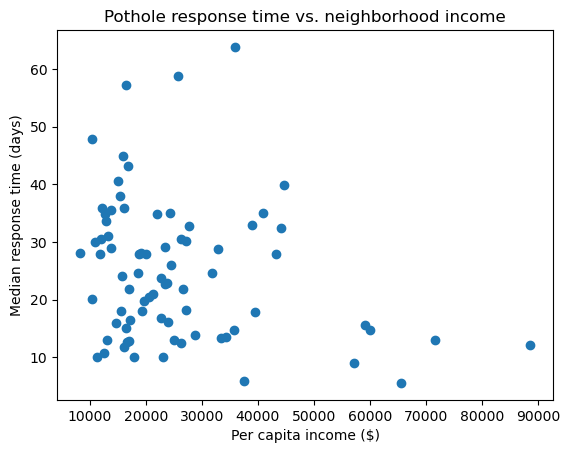

In [28]:
# Scatter of income vs. response time, one dot per community area.
# Visualizes the effect; the loose spread shows how much the trend leaves unexplained.

import matplotlib.pyplot as plt

plt.scatter(area['income'], area['median_response'])
plt.xlabel('Per capita income ($)')
plt.ylabel('Median response time (days)')
plt.title('Pothole response time vs. neighborhood income')
plt.show()

In [29]:
plt.savefig('scatter_income_vs_response.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

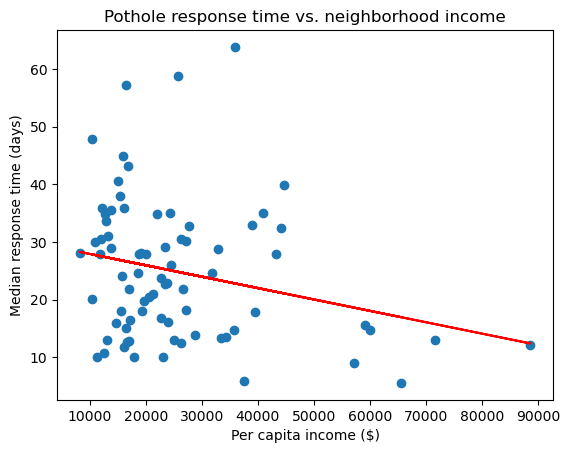

In [30]:
# Same scatter with a best-fit line (np.polyfit degree 1 = straight line).
# The downward slope is the negative income effect made visible.

import matplotlib.pyplot as plt
import numpy as np

plt.scatter(area['income'], area['median_response'])

x = area['income']
y = area['median_response']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

plt.xlabel('Per capita income ($)')
plt.ylabel('Median response time (days)')
plt.title('Pothole response time vs. neighborhood income')

plt.savefig('scatter_income_vs_response.png', dpi=150, bbox_inches='tight')  # save FIRST
plt.show()   # show AFTER

In [31]:
# Attach community-area NAMES from the income file so chart labels read as neighborhoods, not numbers.

names = income[['community_area', 'COMMUNITY AREA NAME']].rename(
    columns={'community_area': 'COMMUNITY_AREA'})
area_named = area.reset_index().merge(names, on='COMMUNITY_AREA', how='left').set_index('COMMUNITY AREA NAME')

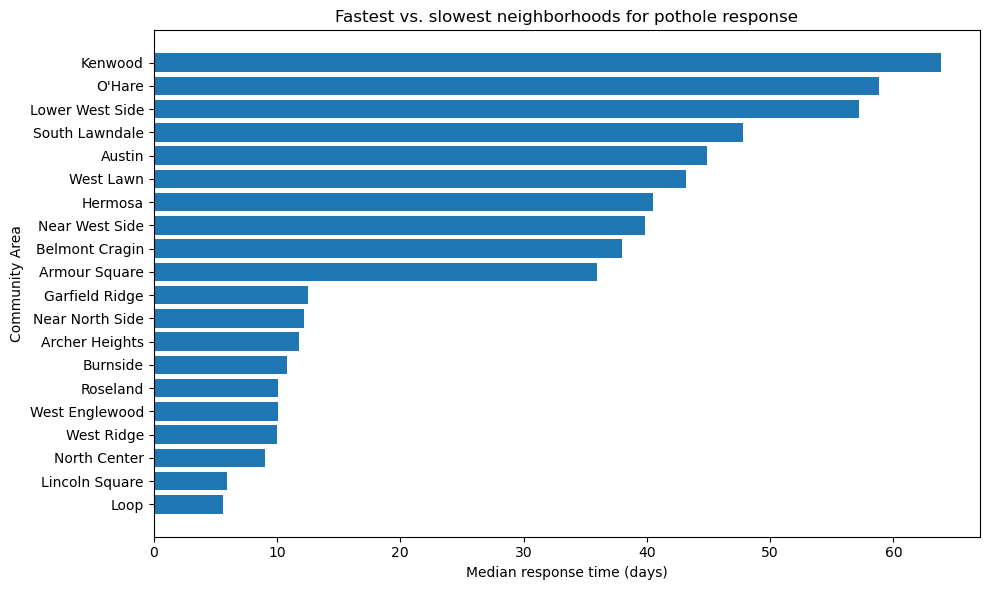

In [32]:
# Horizontal bar chart of the 10 fastest + 10 slowest neighborhoods -- shows the raw ~13x gap.
# barh keeps the neighborhood names readable.

combined = pd.concat([
    area_named.sort_values('median_response').head(10),
    area_named.sort_values('median_response').tail(10)
])

plt.figure(figsize=(10, 6))
plt.barh(combined.index.astype(str), combined['median_response'])
plt.xlabel('Median response time (days)')
plt.ylabel('Community Area')
plt.title('Fastest vs. slowest neighborhoods for pothole response')
plt.tight_layout()
plt.savefig('bar_fastest_slowest.png', dpi=150, bbox_inches='tight')
plt.show()

At the city-wide level there's a weak trend lower-income areas wait modestly longer (the scatter and regression show it). But the extreme cases are driven by other factors: O'Hare is an airport, some slow areas are gentrified, some fast ones are disadvantaged. So income is a real but minor signal, and neighborhood-specific factors land use, infrastructure, request volume — matter more. The data supports a modest association, not a clean inequality narrative.

In [33]:
import statsmodels.api as sm

# Refit the income + volume model using statsmodels instead of sklearn.
# sklearn gave a coefficient and R^2 but no inference; statsmodels adds
# p-values and confidence intervals, which tell me whether the income
# effect is statistically distinguishable from zero given only 77 areas.

X = area[['income', 'volume']]
X = sm.add_constant(X)   # add an intercept column; statsmodels doesn't add one automatically (sklearn did)
y = area['median_response']

# OLS = ordinary least squares: the same linear regression as before,
# from a library that reports the full statistical summary.
model = sm.OLS(y, X).fit()

print(model.summary())   # coefficients, p-values, confidence intervals, R^2

                            OLS Regression Results                            
Dep. Variable:        median_response   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     3.707
Date:                Thu, 18 Jun 2026   Prob (F-statistic):             0.0292
Time:                        14:14:54   Log-Likelihood:                -297.67
No. Observations:                  77   AIC:                             601.3
Df Residuals:                      74   BIC:                             608.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.0205      2.900      9.663      0.0

low p value (under 0.05) -> the pattern is real and unlikely to be luck
high p-value -> pattern might be luck 

In [34]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Standardize predictors so income and volume are on the same scale
# (mean 0, sd 1). Fixes the scale mismatch behind the condition-number
# warning and makes the two coefficients directly comparable.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area[['income', 'volume']])

X_scaled = sm.add_constant(X_scaled)
y = area['median_response']

model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:        median_response   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     3.707
Date:                Thu, 18 Jun 2026   Prob (F-statistic):             0.0292
Time:                        14:14:54   Log-Likelihood:                -297.67
No. Observations:                  77   AIC:                             601.3
Df Residuals:                      74   BIC:                             608.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.8832      1.343     18.530      0.0

Richer neighborhoods have somewhat shorter pothole wait times, and the pattern holds up as probably real rather than chance — income matters more than how busy an area is, though it still explains only a small share of the differences.

In [37]:
import geopandas as gpd

areas_map = gpd.read_file("Boundaries.geojson")
print(areas_map.shape)
areas_map.head()

(77, 10)


,:id,:version,:created_at,:updated_at,area_numbe,community,area_num_1,shape_area,shape_len,geometry
0,row-m77e_pkv8.vjvf,rv-3hjp_vkhx~fqfx,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,row-u375_347e-y6q8,rv-tgcx_t7fr-nkkg,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,row-kgqf-m29p-99kg,rv-bag4-8zri.nvhu,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,3,UPTOWN,3,65095642.7289,46972.7945549,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,row-2dpv_pk9x-zybp,rv-82s2~rb54~emuc,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,4,LINCOLN SQUARE,4,71352328.2399,36624.6030848,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,row-37zy.7r75.56p7,rv-hrse.ahu7-rz4d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,5,NORTH CENTER,5,57054167.85,31391.6697542,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [42]:
# Convert the area number from text to integer so it matches my data's key.
areas_map['area_numbe'] = areas_map['area_numbe'].astype(int)

# Attach my per-area data (response time, income, volume) onto each polygon
# by matching community-area number. Left join keeps all 77 map areas.
geo = areas_map.merge(
    area.reset_index(),
    left_on='area_numbe',
    right_on='COMMUNITY_AREA',
    how='left'
)

# Verify the join worked: 0 nulls means every map area found its response-time data.
print(geo.shape)
print(geo['median_response'].isnull().sum())


(77, 15)
0


In [43]:
from libpysal.weights import Queen

# Build a spatial weights object: for each community area, find which other
# areas physically touch it. "Queen" contiguity counts areas as neighbors if
# they share any border or corner. This encodes the geography the regression ignored.
w = Queen.from_dataframe(geo, use_index=False)
w.transform = 'r'   # row-standardize: turn neighbor relationships into averages

In [44]:
from esda.moran import Moran

# Moran's I tests whether nearby areas have similar response times.
# Positive + significant = response times cluster geographically (neighbors are alike),
# which means the areas aren't independent — the assumption my regression relied on.
mi = Moran(geo['median_response'], w)

print("Moran's I:", mi.I)        # ranges ~ -1 to +1; positive = clustering
print("p-value:", mi.p_sim)      # is the clustering statistically real, or chance?

Moran's I: 0.298394294902251
p-value: 0.001


I tested for spatial autocorrelation (Moran's I = 0.30, p = 0.001) and found response times cluster geographically — neighboring community areas have similar wait times. This means the areas aren't fully independent, so my regression's standard errors are likely slightly optimistic. The income association still holds, but its statistical precision should be read with that caveat. A spatial regression model would be the proper next step.